In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

mi_scores = pd.read_csv('mi_results.csv')   

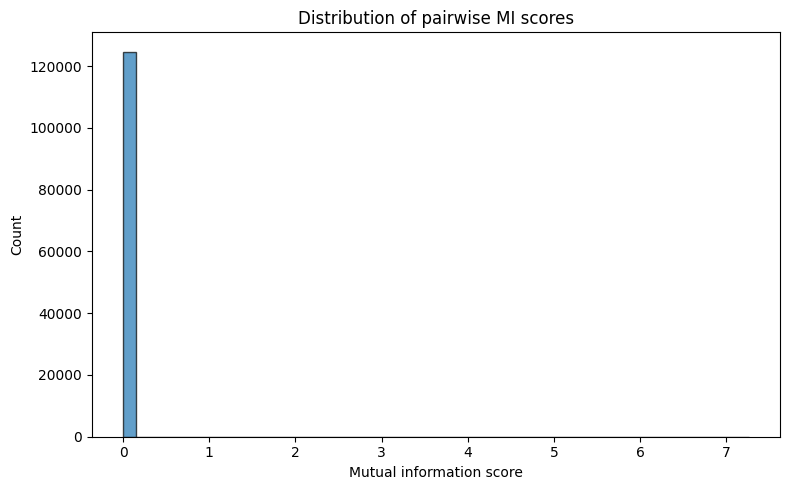

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(mi_scores['mi_score'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Mutual information score')
plt.ylabel('Count')
plt.title('Distribution of pairwise MI scores')
plt.tight_layout()
plt.show()

In [9]:
print(pd.cut(mi_scores['mi_score'], bins=50).value_counts().sort_index())

mi_score
(-0.00726, 0.145]    124680
(0.145, 0.29]            10
(0.29, 0.436]            28
(0.436, 0.581]           15
(0.581, 0.726]            3
(0.726, 0.871]            4
(0.871, 1.017]            0
(1.017, 1.162]            0
(1.162, 1.307]            2
(1.307, 1.452]            0
(1.452, 1.597]            0
(1.597, 1.743]            6
(1.743, 1.888]            0
(1.888, 2.033]            0
(2.033, 2.178]            0
(2.178, 2.324]            0
(2.324, 2.469]            0
(2.469, 2.614]            0
(2.614, 2.759]            0
(2.759, 2.904]            0
(2.904, 3.05]             0
(3.05, 3.195]             0
(3.195, 3.34]             0
(3.34, 3.485]             0
(3.485, 3.63]             0
(3.63, 3.776]             0
(3.776, 3.921]            0
(3.921, 4.066]            0
(4.066, 4.211]            0
(4.211, 4.357]            0
(4.357, 4.502]            0
(4.502, 4.647]            0
(4.647, 4.792]            0
(4.792, 4.937]            0
(4.937, 5.083]            0
(5.083, 5.2

In [10]:
high_mi = mi_scores[mi_scores['mi_score'] > 1.0]
high_mi

,feature_i,feature_j,mi_score
15146,31,174,7.260976
15147,31,175,1.617777
15236,31,264,1.277620
67035,159,415,7.260976
71775,174,175,1.617777
71864,174,264,1.277620
72188,175,264,1.620253
77008,190,344,1.622194
79354,198,254,1.626811
106433,308,328,1.629976


In [13]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data import load_data

def get_columns_to_drop(
    mi_pairs: pd.DataFrame,
    X: np.ndarray,
    y: np.ndarray,
    mi_threshold: float = 1.0,
    random_state: int = 0,
) -> tuple[list[int], pd.DataFrame]:
    """
    Identifies redundant features based on pairwise Mutual Information scores.

    For all feature pairs where pairwise MI exceeds the threshold, the feature 
    with the lower Mutual Information score with the target is selected for removal.

    Args:
        mi_pairs: DataFrame with 'feature_i', 'feature_j', and 'mi_score' columns.
        X: The input feature matrix.
        y: The target array.
        mi_threshold: The MI score threshold for redundancy.
        random_state: Random seed for reproducibility.

    Returns:
        drop_columns: A sorted list of feature indices to be dropped.
        decisions_df: A DataFrame detailing the redundancy conflict resolution.
    """
    high_mi_pairs = mi_pairs[mi_pairs['mi_score'] > mi_threshold].copy()
    
    # Calculate MI scores for each feature relative to the target
    mi_with_target = mutual_info_classif(X, y, random_state=random_state)

    to_drop: set[int] = set()
    decisions = []

    for _, row in high_mi_pairs.iterrows():
        i, j = int(row['feature_i']), int(row['feature_j'])
        
        # Skip if one of them is already marked for removal
        if i in to_drop or j in to_drop:
            continue

        mi_i, mi_j = mi_with_target[i], mi_with_target[j]

        # Drop the feature that is less informative for the target
        if mi_i < mi_j:
            drop_col, keep_col = i, j
        elif mi_j < mi_i:
            drop_col, keep_col = j, i
        else:
            # If equally informative, drop the higher index arbitrarily
            drop_col, keep_col = max(i, j), min(i, j)

        to_drop.add(drop_col)
        decisions.append({
            'feature_i': i,
            'feature_j': j,
            'pairwise_mi': row['mi_score'],
            'mi_i_with_target': mi_i,
            'mi_j_with_target': mi_j,
            'drop_column': drop_col,
            'keep_column': keep_col,
        })

    drop_columns = sorted(to_drop)
    decisions_df = pd.DataFrame(decisions)
    
    return drop_columns, decisions_df


_, y_train, _, X_train, X_test, _ = load_data()
drop_columns, drop_decisions = get_columns_to_drop(mi_scores, X_train, y_train)

print(f'Columns to drop (indices): {drop_columns}')
print(f'Total features to drop: {len(drop_columns)}')
drop_decisions

Columns to drop (indices): [31, 174, 198, 264, 328, 344, 415]
Total features to drop: 7


,feature_i,feature_j,pairwise_mi,mi_i_with_target,mi_j_with_target,drop_column,keep_column
0,31,174,7.260976,0.006394,0.006394,174,31
1,31,175,1.617777,0.006394,0.018041,31,175
2,159,415,7.260976,0.018163,0.018163,415,159
3,175,264,1.620253,0.018041,0.015911,264,175
4,190,344,1.622194,0.016577,0.009262,344,190
5,198,254,1.626811,0.008195,0.017258,198,254
6,308,328,1.629976,0.009498,0.001848,328,308


Based on mutual information we have to drop 7 columns

In [14]:
def feature_name(idx: int) -> str:
    return f'V{idx + 1}'


keep_columns = np.setdiff1d(np.arange(X_train.shape[1]), drop_columns)
column_names = [feature_name(i) for i in keep_columns]

X_train_reduced = pd.DataFrame(X_train[:, keep_columns], columns=column_names)
X_test_reduced = pd.DataFrame(X_test[:, keep_columns], columns=column_names)

X_train_reduced.to_csv('../data/x_train_scaled_reduced_after_mi.csv', index=False)
X_test_reduced.to_csv('../data/x_test_scaled_reduced_after_mi.csv', index=False)

print(f'Dropped: {[feature_name(i) for i in drop_columns]}')
print(f'Kept (first/last): {column_names[:5]} ... {column_names[-5:]}')
print(f'Shape train: {X_train.shape} -> {X_train_reduced.shape}')
print(f'Shape test:  {X_test.shape} -> {X_test_reduced.shape}')

Dropped: ['V32', 'V175', 'V199', 'V265', 'V329', 'V345', 'V416']
Kept (first/last): ['V1', 'V2', 'V3', 'V4', 'V5'] ... ['V496', 'V497', 'V498', 'V499', 'V500']
Shape train: (5000, 500) -> (5000, 493)
Shape test:  (5000, 500) -> (5000, 493)
